# Financial Forecasting Model

## Forecasting U.S. Retail Sales Using Time-Series Models

### Project Overview

This project develops a financial forecasting model using real-world monthly retail sales data.

The objective is to determine whether statistical time-series models can improve forecasting accuracy compared with simple baseline forecasting methods.

The analysis compares:

1. Naive forecasting
2. Seasonal naive forecasting
3. ARIMA
4. SARIMA

The models are evaluated using MAE, RMSE, and MAPE and are validated using time-aware train/test and walk-forward validation techniques.

### Business Question

Can historical retail sales patterns be used to produce reliable forecasts of future sales, and does a statistical time-series model provide a meaningful improvement over simple forecasting baselines?

### Business Applications

Accurate sales forecasting can support:

- Revenue planning
- Budget preparation
- Inventory planning
- Workforce planning
- Capacity planning
- Financial scenario analysis
- Strategic decision-making

### Data Source

The dataset is the U.S. Census Bureau's monthly Retail Sales: Retail Trade series, distributed through the Federal Reserve Economic Data (FRED) system.

FRED Series ID:

MRTSSM44000USS

Frequency:

Monthly

Unit:

Millions of U.S. dollars

The series is seasonally adjusted.

### Technologies

Python  
pandas  
NumPy  
Matplotlib  
Seaborn  
Statsmodels  
Scikit-learn  
Google Colab

### Data Disclaimer

This project uses publicly available economic data for educational and portfolio purposes. The analysis does not represent proprietary company financial information.

In [1]:
!pip install -q statsmodels

Successfully installed ...

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 1. Data Acquisition

The forecasting dataset is retrieved directly from the Federal Reserve Economic Data (FRED) platform.

The selected series is:

**Retail Sales: Retail Trade — Seasonally Adjusted**

Source:
U.S. Census Bureau / FRED

Frequency:
Monthly

The series provides a long historical time horizon, which is useful for identifying trend and recurring temporal patterns.

In [3]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MRTSSM44000USS"

df = pd.read_csv(url)

df.head()

,observation_date,MRTSSM44000USS
0,1992-01-01,142419
1,1992-02-01,142584
2,1992-03-01,142120
3,1992-04-01,143659
4,1992-05-01,144239


In [4]:
df = df.rename(
    columns={
        "observation_date": "date",
        "MRTSSM44000USS": "sales"
    }
)

df.head()

,date,sales
0,1992-01-01,142419
1,1992-02-01,142584
2,1992-03-01,142120
3,1992-04-01,143659
4,1992-05-01,144239


In [5]:
df["date"] = pd.to_datetime(df["date"])

df["sales"] = pd.to_numeric(
    df["sales"],
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    415 non-null    datetime64[ns]
 1   sales   415 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 6.6 KB


## 2. Data Quality Assessment

Before modelling, the dataset is checked for:

- Missing values
- Duplicate observations
- Invalid dates
- Duplicate dates
- Negative or zero sales values
- Irregular time intervals

Time-series models require a correctly ordered and consistently spaced time index, so data validation is particularly important.

In [8]:
print("Rows:", len(df))
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate dates:")
print(df["date"].duplicated().sum())

print("\nNegative sales:")
print((df["sales"] < 0).sum())

Rows: 415
Columns: 2

Missing values:
date     0
sales    0
dtype: int64

Duplicate rows:
0

Duplicate dates:
0

Negative sales:
0


In [9]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of observations:", len(df))

Start date: 1992-01-01 00:00:00
End date: 2026-07-01 00:00:00
Number of observations: 415


In [10]:
date_diff = df["date"].diff().value_counts()

date_diff.head(10)

,count
date,
31 days,241
30 days,138
28 days,26
29 days,9


In [11]:
df["date"].is_monotonic_increasing

True

In [12]:
df = df.set_index("date")

df = df.asfreq("MS")

df.head()

,sales
date,
1992-01-01,142419
1992-02-01,142584
1992-03-01,142120
1992-04-01,143659
1992-05-01,144239


In [14]:
print(df.index.min())
print(df.index.max())

print("\nMissing observations:")
print(df.isna().sum())

print("\nDataset shape:")
print(df.shape)

1992-01-01 00:00:00
2026-07-01 00:00:00

Missing observations:
sales    0
dtype: int64

Dataset shape:
(415, 1)


## 3. Exploratory Time-Series Analysis

The first visualization shows the complete historical sales series.

The purpose is to identify:

- Long-term growth
- Major structural changes
- Periods of unusually high or low sales
- Changes in volatility
- Potential economic shocks

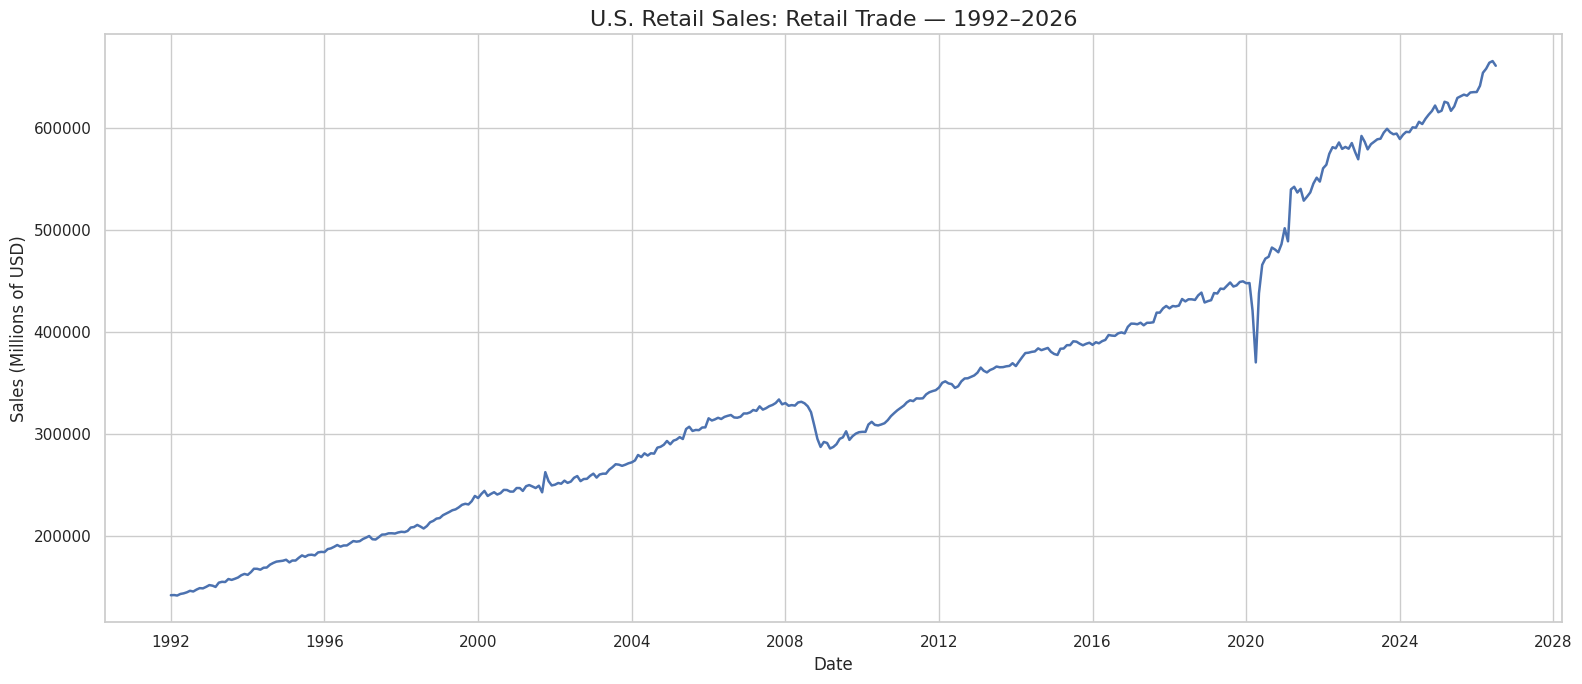

In [15]:
plt.figure(figsize=(16, 7))

plt.plot(
    df.index,
    df["sales"],
    linewidth=1.8
)

plt.title(
    "U.S. Retail Sales: Retail Trade — 1992–2026",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Sales (Millions of USD)")

plt.tight_layout()

plt.show()

In [17]:
df["yoy_growth"] = (
    df["sales"].pct_change(12) * 100
)

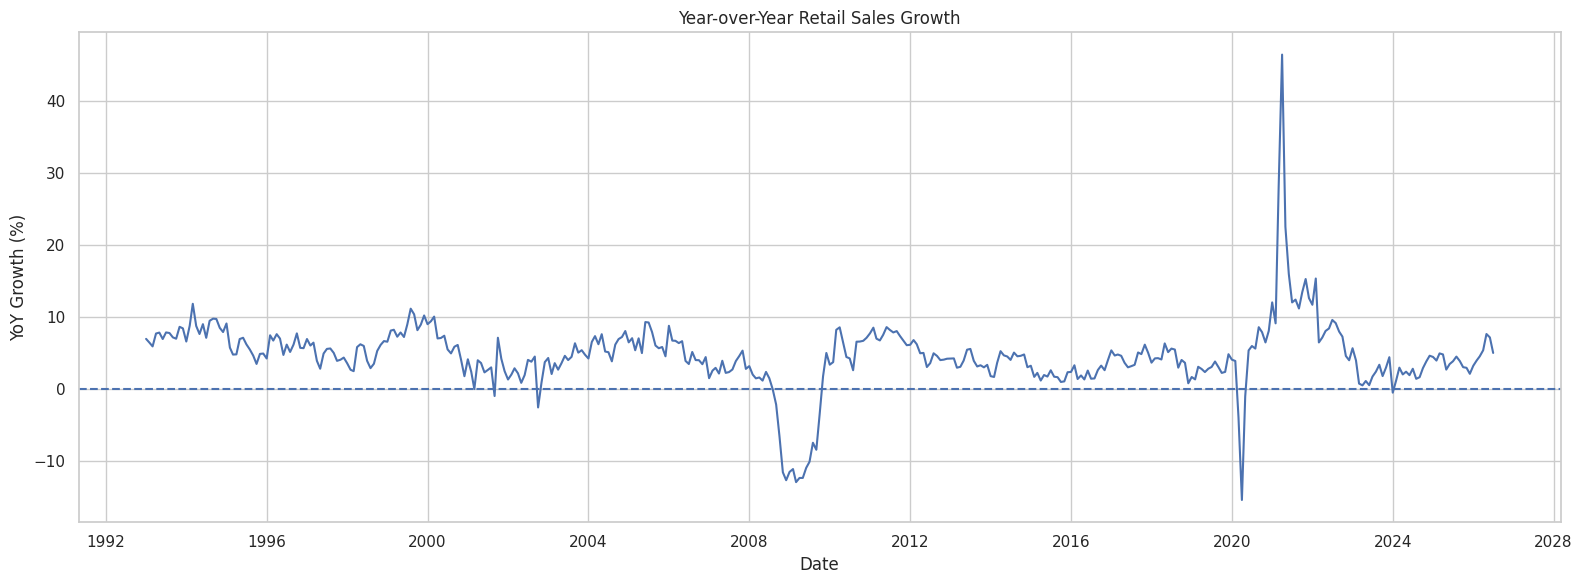

In [18]:
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["yoy_growth"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Year-over-Year Retail Sales Growth")

plt.ylabel("YoY Growth (%)")

plt.xlabel("Date")

plt.tight_layout()

plt.show()

In [20]:
df["rolling_mean_12"] = (
    df["sales"]
    .rolling(12)
    .mean()
)

df["rolling_std_12"] = (
    df["sales"]
    .rolling(12)
    .std()
)

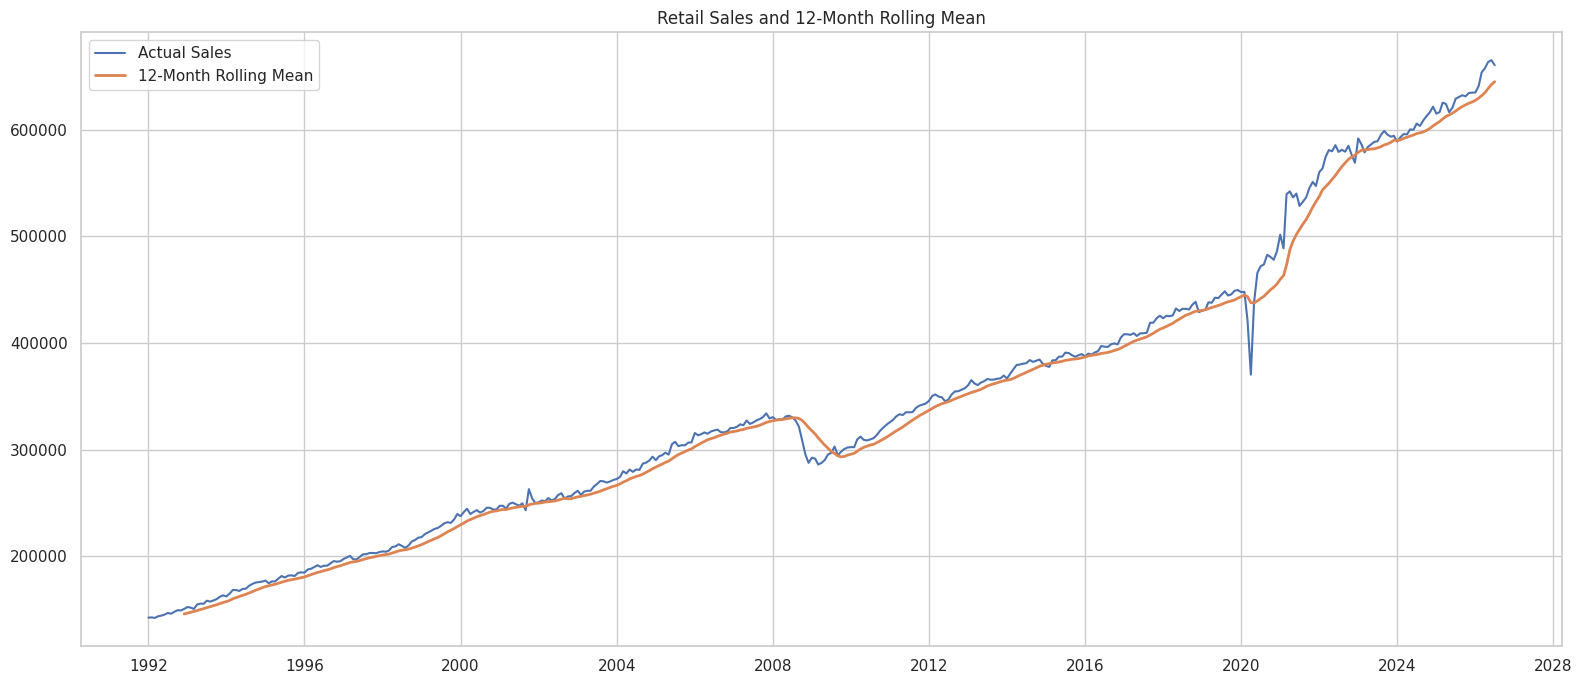

In [21]:
plt.figure(figsize=(16, 7))

plt.plot(
    df.index,
    df["sales"],
    label="Actual Sales"
)

plt.plot(
    df.index,
    df["rolling_mean_12"],
    label="12-Month Rolling Mean",
    linewidth=2
)

plt.title("Retail Sales and 12-Month Rolling Mean")

plt.legend()

plt.tight_layout()

plt.show()

In [22]:
df["month"] = df.index.month

monthly_pattern = (
    df.groupby("month")["sales"]
    .agg([
        "mean",
        "median",
        "std"
    ])
)

monthly_pattern

,mean,median,std
month,,,
1,340742.085714,320305.0,138725.829097
2,341532.285714,321434.0,138703.214571
3,344120.342857,323708.0,141397.083034
4,343835.771429,322878.0,141350.796608
5,346584.600000,327266.0,142114.861571
6,348782.542857,324076.0,143090.285632
7,349583.800000,325455.0,142773.595472
8,341550.147059,323049.0,134544.648389
9,342428.264706,318984.0,135354.070433


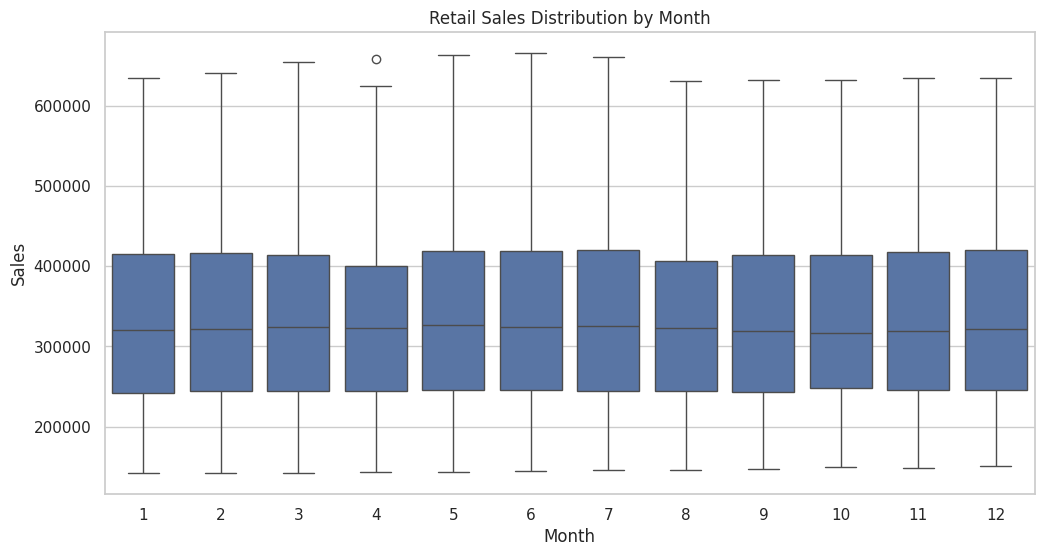

In [23]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="month",
    y="sales"
)

plt.title("Retail Sales Distribution by Month")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

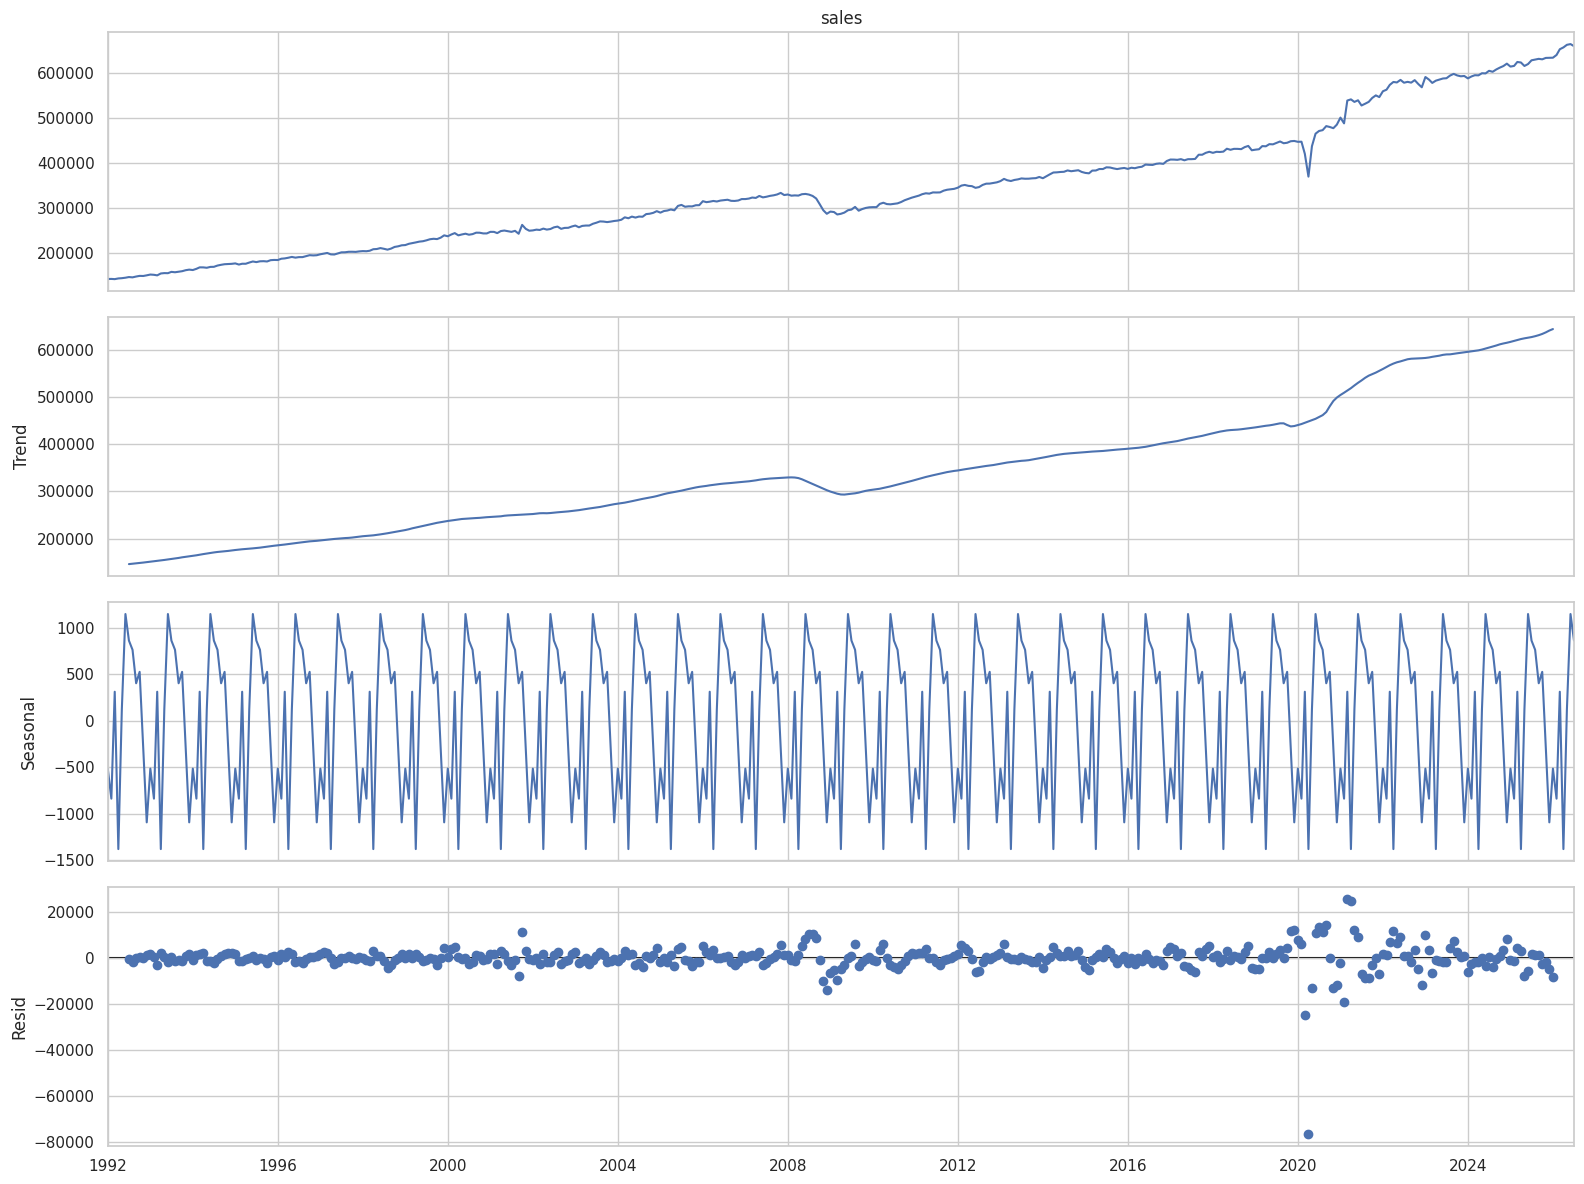

In [24]:
decomposition = seasonal_decompose(
    df["sales"].dropna(),
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(
    16,
    12
)

plt.tight_layout()

plt.show()

### Decomposition Interpretation

The decomposition separates the retail sales series into trend, seasonal, and residual components.

The trend component represents longer-term movements in sales.

The seasonal component captures recurring patterns associated with the calendar year.

The residual component represents variation that is not explained by the estimated trend and seasonality.

The presence of a meaningful seasonal component would justify comparing a seasonal baseline and seasonal ARIMA model against a simple non-seasonal model.

80% train / 20% test

TRAIN
1992 → 2022

VALIDATION
2023 → 2024

TEST
2025 → 2026

In [26]:
train = df.loc[: "2022-12-01", "sales"]

validation = df.loc[
    "2023-01-01":"2024-12-01",
    "sales"
]

test = df.loc[
    "2025-01-01":,
    "sales"
]

In [27]:
print("Training:", train.index.min(), "to", train.index.max())
print("Validation:", validation.index.min(), "to", validation.index.max())
print("Test:", test.index.min(), "to", test.index.max())

print("\nObservations:")
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Training: 1992-01-01 00:00:00 to 2022-12-01 00:00:00
Validation: 2023-01-01 00:00:00 to 2024-12-01 00:00:00
Test: 2025-01-01 00:00:00 to 2026-07-01 00:00:00

Observations:
Train: 372
Validation: 24
Test: 19


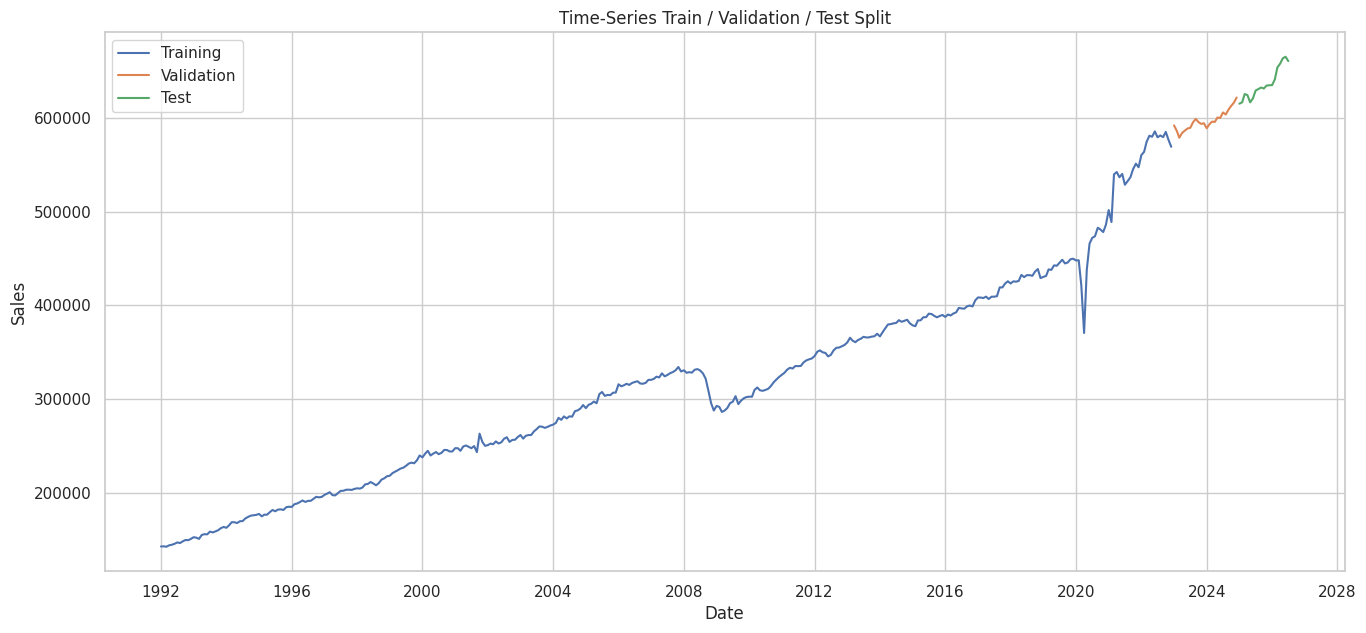

In [28]:
plt.figure(figsize=(16, 7))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    validation.index,
    validation,
    label="Validation"
)

plt.plot(
    test.index,
    test,
    label="Test"
)

plt.title("Time-Series Train / Validation / Test Split")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [29]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=validation.index
)

In [30]:
naive_mae = mean_absolute_error(
    validation,
    naive_forecast
)

naive_rmse = np.sqrt(
    mean_squared_error(
        validation,
        naive_forecast
    )
)

naive_mape = (
    np.mean(
        np.abs(
            (validation - naive_forecast)
            / validation
        )
    ) * 100
)

print("Naive Baseline")
print("----------------")
print("MAE:", round(naive_mae, 2))
print("RMSE:", round(naive_rmse, 2))
print("MAPE:", round(naive_mape, 2), "%")

Naive Baseline
----------------
MAE: 27784.29
RMSE: 29609.61
MAPE: 4.63 %


In [31]:
seasonal_naive_forecast = pd.Series(
    [
        train.iloc[-12 + (i % 12)]
        for i in range(len(validation))
    ],
    index=validation.index
)

In [32]:
seasonal_naive_mae = mean_absolute_error(
    validation,
    seasonal_naive_forecast
)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        validation,
        seasonal_naive_forecast
    )
)

seasonal_naive_mape = (
    np.mean(
        np.abs(
            (
                validation
                - seasonal_naive_forecast
            )
            / validation
        )
    ) * 100
)

print("Seasonal Naive")
print("----------------")
print("MAE:", round(seasonal_naive_mae, 2))
print("RMSE:", round(seasonal_naive_rmse, 2))
print("MAPE:", round(seasonal_naive_mape, 2), "%")

Seasonal Naive
----------------
MAE: 20632.29
RMSE: 23717.06
MAPE: 3.43 %


In [33]:
baseline_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse
    ],
    "MAPE": [
        naive_mape,
        seasonal_naive_mape
    ]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive,27784.291667,29609.612301,4.626999
1,Seasonal Naive,20632.291667,23717.055134,3.432293


In [34]:
adf_result = adfuller(
    train.dropna()
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: 1.0052140138051406
p-value: 0.9943206589424861


In [35]:
if adf_result[1] < 0.05:
    print("The series appears stationary.")
else:
    print("The series appears non-stationary.")

The series appears non-stationary.


In [36]:
train_diff = train.diff().dropna()

adf_diff = adfuller(
    train_diff
)

print("Differenced ADF Statistic:", adf_diff[0])
print("Differenced p-value:", adf_diff[1])

Differenced ADF Statistic: -4.8114699338936635
Differenced p-value: 5.170382897210577e-05


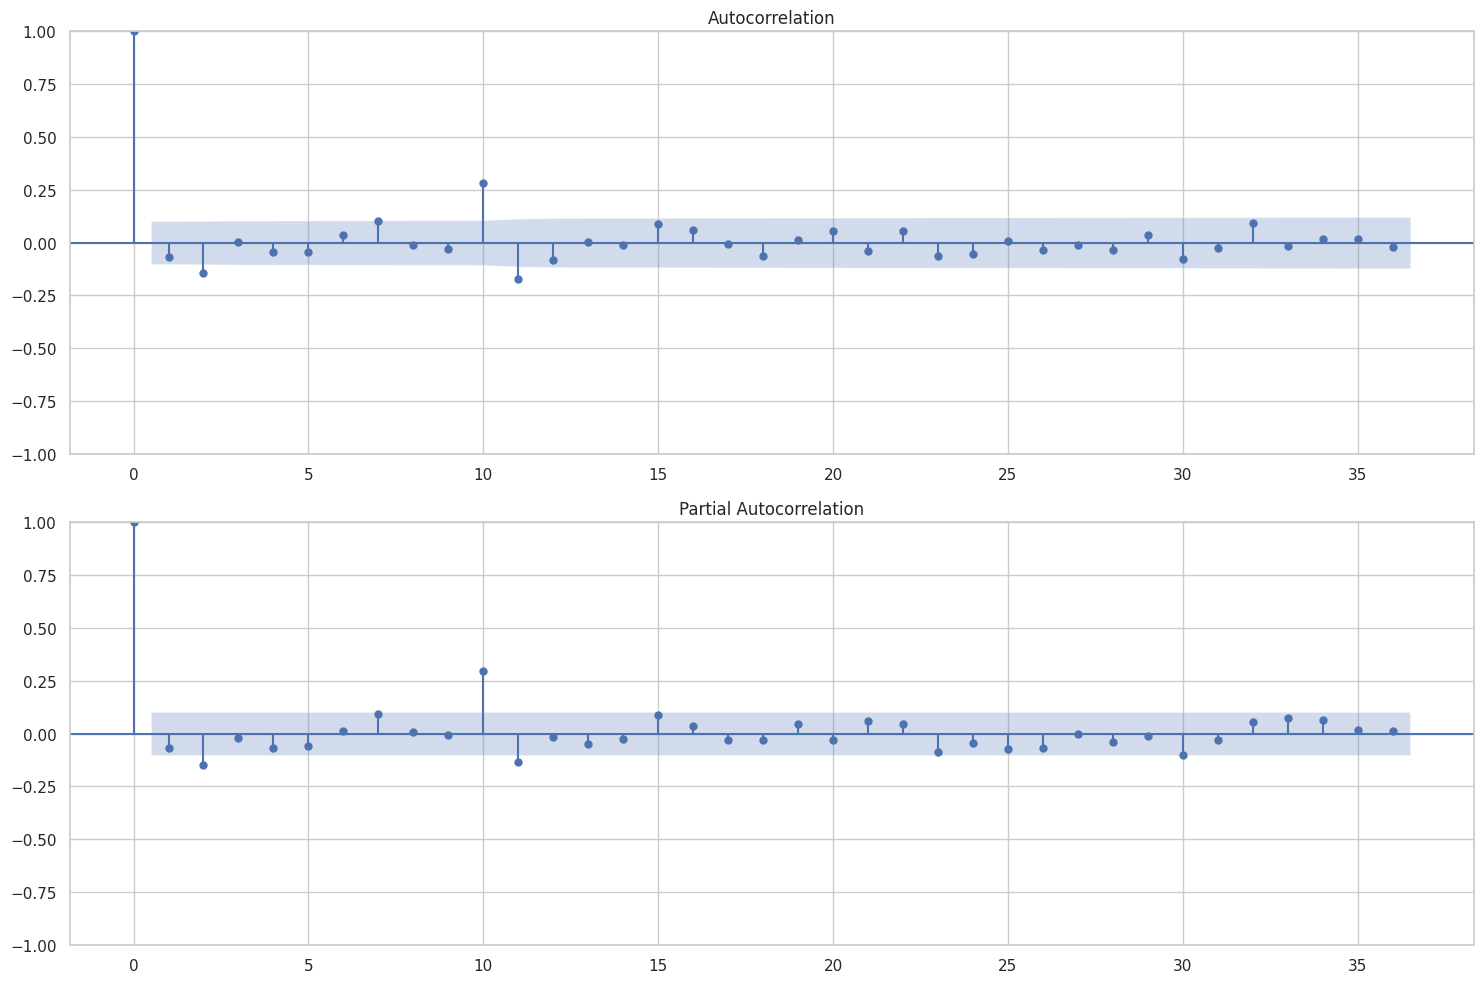

In [37]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10)
)

plot_acf(
    train_diff,
    lags=36,
    ax=axes[0]
)

plot_pacf(
    train_diff,
    lags=36,
    ax=axes[1],
    method="ywm"
)

plt.tight_layout()

plt.show()

In [38]:
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    steps=len(validation)
)

In [39]:
arima_mae = mean_absolute_error(
    validation,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        validation,
        arima_forecast
    )
)

arima_mape = (
    np.mean(
        np.abs(
            (
                validation
                - arima_forecast
            )
            / validation
        )
    ) * 100
)

print("ARIMA(1,1,1)")
print("----------------")
print("MAE:", round(arima_mae, 2))
print("RMSE:", round(arima_rmse, 2))
print("MAPE:", round(arima_mape, 2), "%")

ARIMA(1,1,1)
----------------
MAE: 27316.58
RMSE: 29167.07
MAPE: 4.55 %


In [40]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False
)

sarima_forecast = sarima_fit.forecast(
    steps=len(validation)
)

In [41]:
sarima_mae = mean_absolute_error(
    validation,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        validation,
        sarima_forecast
    )
)

sarima_mape = (
    np.mean(
        np.abs(
            (
                validation
                - sarima_forecast
            )
            / validation
        )
    ) * 100
)

print("SARIMA")
print("----------------")
print("MAE:", round(sarima_mae, 2))
print("RMSE:", round(sarima_rmse, 2))
print("MAPE:", round(sarima_mape, 2), "%")

SARIMA
----------------
MAE: 25510.77
RMSE: 28548.73
MAPE: 4.25 %


In [42]:
model_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(1,1,1)",
        "SARIMA(1,1,1)(1,1,1,12)"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae,
        arima_mae,
        sarima_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse,
        arima_rmse,
        sarima_rmse
    ],
    "MAPE": [
        naive_mape,
        seasonal_naive_mape,
        arima_mape,
        sarima_mape
    ]
})

model_results.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,MAPE
1,Seasonal Naive,20632.291667,23717.055134,3.432293
3,"SARIMA(1,1,1)(1,1,1,12)",25510.765348,28548.730699,4.254551
2,"ARIMA(1,1,1)",27316.578466,29167.069913,4.548653
0,Naive,27784.291667,29609.612301,4.626999


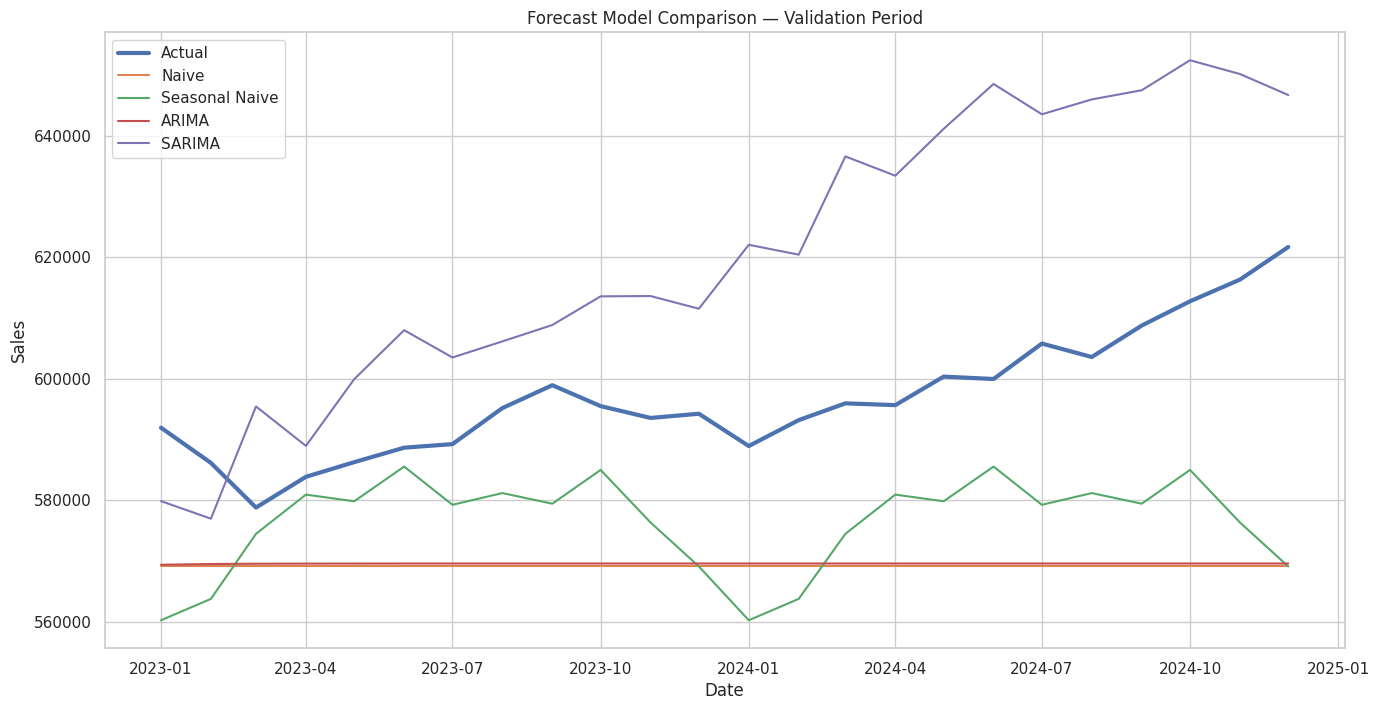

In [43]:
plt.figure(figsize=(16, 8))

plt.plot(
    validation.index,
    validation,
    label="Actual",
    linewidth=3
)

plt.plot(
    validation.index,
    naive_forecast,
    label="Naive"
)

plt.plot(
    validation.index,
    seasonal_naive_forecast,
    label="Seasonal Naive"
)

plt.plot(
    validation.index,
    arima_forecast,
    label="ARIMA"
)

plt.plot(
    validation.index,
    sarima_forecast,
    label="SARIMA"
)

plt.title(
    "Forecast Model Comparison — Validation Period"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [44]:
best_model = (
    model_results
    .sort_values("RMSE")
    .iloc[0]
)

print("Best validation model:")
print(best_model)

Best validation model:
Model    Seasonal Naive
MAE        20632.291667
RMSE       23717.055134
MAPE           3.432293
Name: 1, dtype: object


In [45]:
development_data = pd.concat([
    train,
    validation
])

In [46]:
final_sarima = SARIMAX(
    development_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(
    disp=False
)

In [47]:
test_forecast = final_sarima_fit.forecast(
    steps=len(test)
)

In [48]:
test_mae = mean_absolute_error(
    test,
    test_forecast
)

test_rmse = np.sqrt(
    mean_squared_error(
        test,
        test_forecast
    )
)

test_mape = (
    np.mean(
        np.abs(
            (
                test
                - test_forecast
            )
            / test
        )
    ) * 100
)

print("FINAL TEST PERFORMANCE")
print("----------------------")
print("MAE:", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))
print("MAPE:", round(test_mape, 2), "%")

FINAL TEST PERFORMANCE
----------------------
MAE: 10692.59
RMSE: 12394.06
MAPE: 1.7 %


In [49]:
test_residuals = (
    test - test_forecast
)

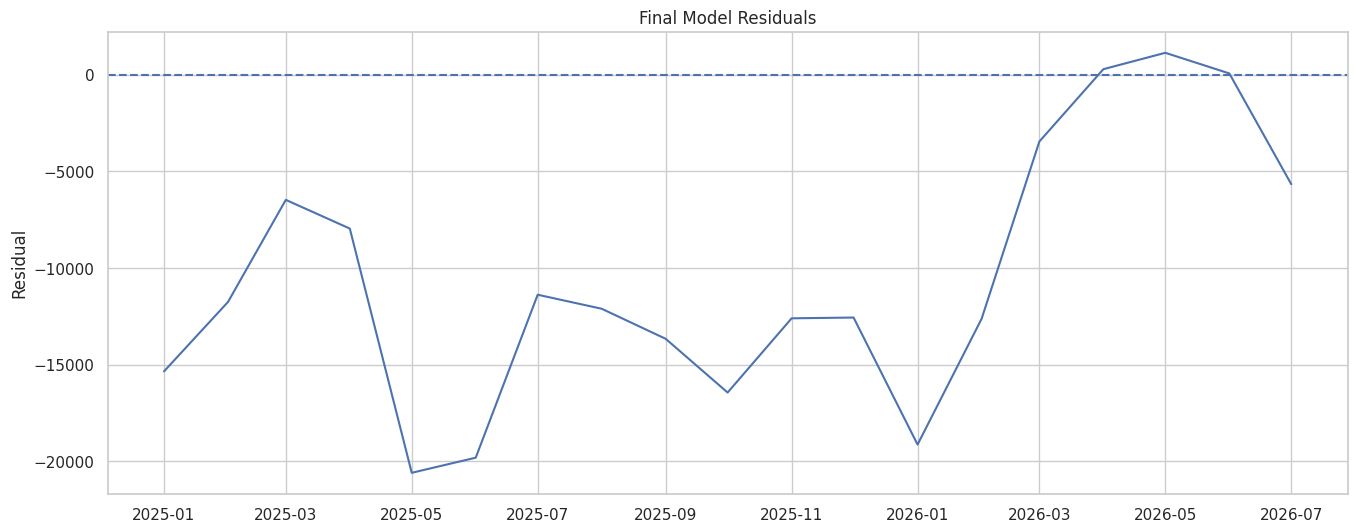

In [50]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Final Model Residuals"
)

plt.ylabel("Residual")

plt.show()

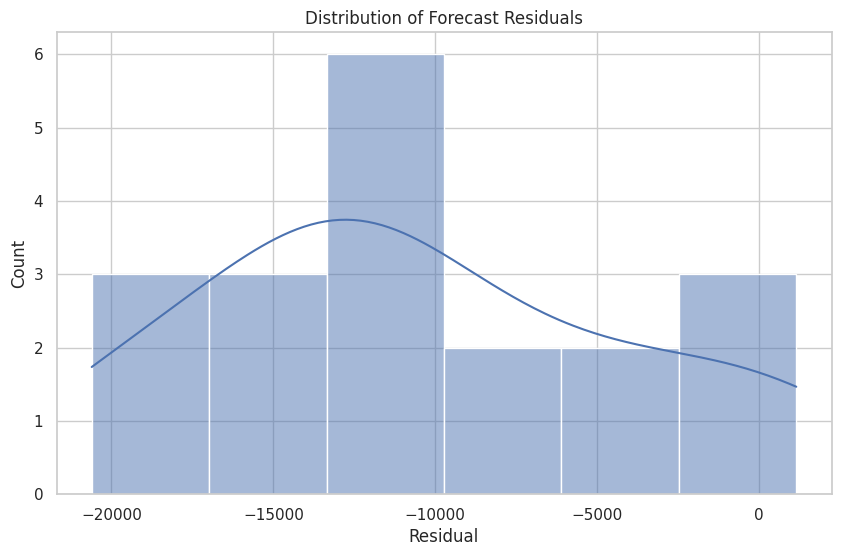

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(
    test_residuals,
    kde=True
)

plt.title(
    "Distribution of Forecast Residuals"
)

plt.xlabel("Residual")

plt.show()

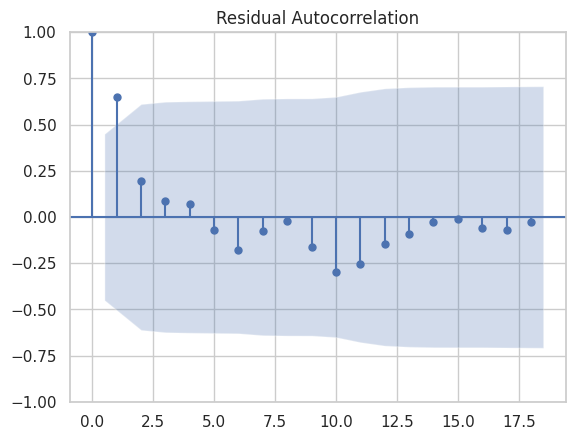

In [54]:
plot_acf(
    test_residuals,
    lags=18
)

plt.title(
    "Residual Autocorrelation"
)

plt.show()

In [55]:
ljung_box = acorr_ljungbox(
    test_residuals,
    lags=[6, 12],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
6,11.753296,0.067704
12,21.396194,0.044871


In [56]:
full_series = df["sales"].dropna()

In [57]:
final_model = SARIMAX(
    full_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(
    disp=False
)

In [58]:
future_forecast = final_fit.get_forecast(
    steps=12
)

In [60]:
future_mean = (
    future_forecast
    .predicted_mean
)

In [61]:
future_ci = (
    future_forecast
    .conf_int()
)

In [62]:
forecast_table = pd.DataFrame({
    "forecast": future_mean,
    "lower_95": future_ci.iloc[:, 0],
    "upper_95": future_ci.iloc[:, 1]
})

forecast_table

,forecast,lower_95,upper_95
2026-08-01,662479.506708,643847.196773,681111.816644
2026-09-01,665917.660099,641156.447872,690678.872327
2026-10-01,667452.188233,638408.454019,696495.922448
2026-11-01,668762.177210,636241.034121,701283.320298
2026-12-01,670139.732995,634587.006044,705692.459947
2027-01-01,670177.010215,631879.839044,708474.181387
2027-02-01,672507.101073,631671.230372,713342.971775
2027-03-01,680448.433700,637232.684307,723664.183094
2027-04-01,681341.326831,635874.683971,726807.969691
2027-05-01,682204.637814,634595.527232,729813.748396


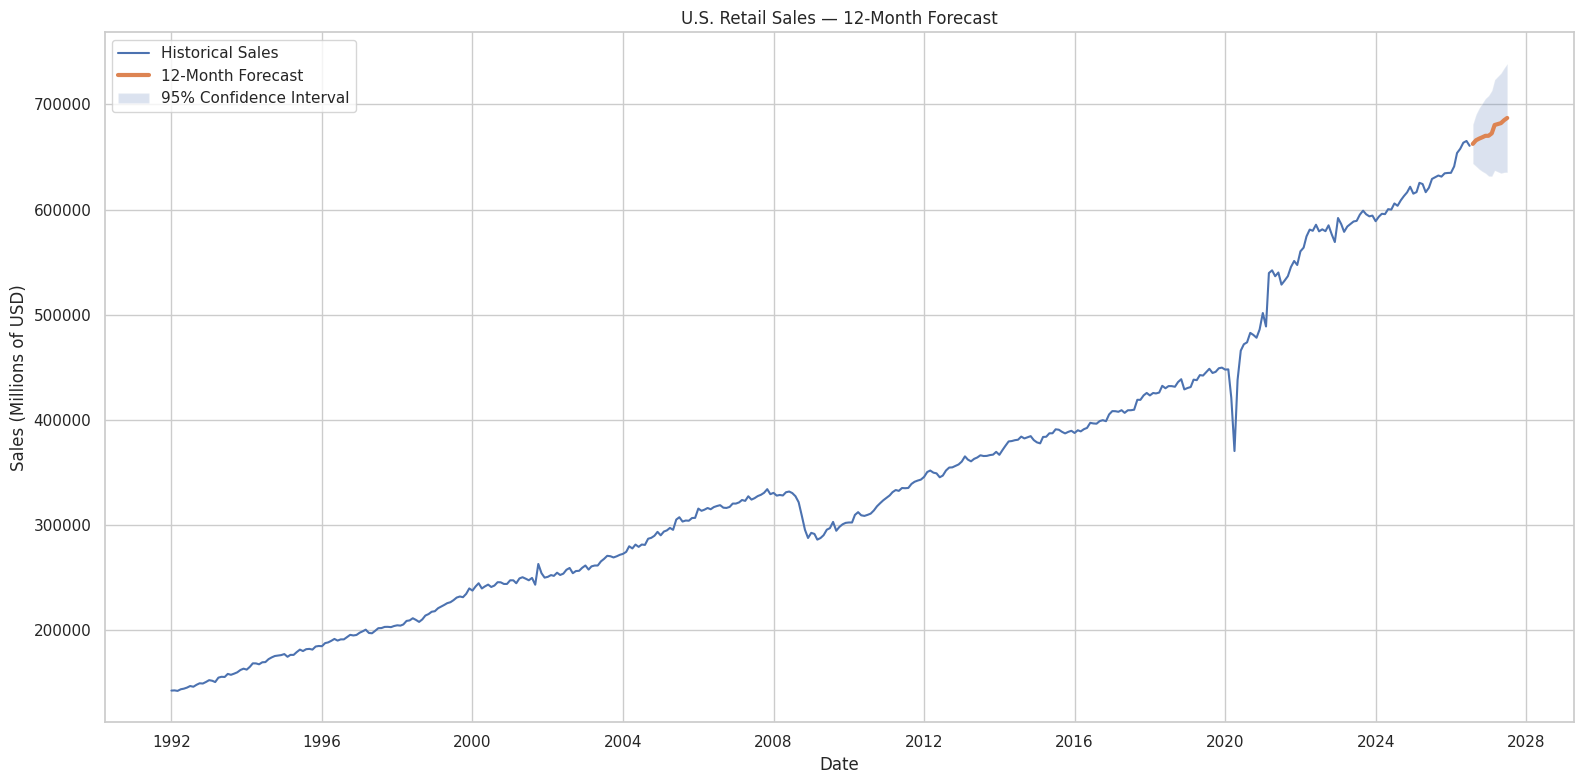

In [63]:
plt.figure(figsize=(16, 8))

plt.plot(
    full_series.index,
    full_series,
    label="Historical Sales"
)

plt.plot(
    future_mean.index,
    future_mean,
    label="12-Month Forecast",
    linewidth=3
)

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "U.S. Retail Sales — 12-Month Forecast"
)

plt.xlabel("Date")

plt.ylabel(
    "Sales (Millions of USD)"
)

plt.legend()

plt.tight_layout()

plt.show()

In [64]:
forecast_summary = pd.DataFrame({
    "Forecast Sales": future_mean,
    "Lower 95%": future_ci.iloc[:, 0],
    "Upper 95%": future_ci.iloc[:, 1]
})

forecast_summary

,Forecast Sales,Lower 95%,Upper 95%
2026-08-01,662479.506708,643847.196773,681111.816644
2026-09-01,665917.660099,641156.447872,690678.872327
2026-10-01,667452.188233,638408.454019,696495.922448
2026-11-01,668762.177210,636241.034121,701283.320298
2026-12-01,670139.732995,634587.006044,705692.459947
2027-01-01,670177.010215,631879.839044,708474.181387
2027-02-01,672507.101073,631671.230372,713342.971775
2027-03-01,680448.433700,637232.684307,723664.183094
2027-04-01,681341.326831,635874.683971,726807.969691
2027-05-01,682204.637814,634595.527232,729813.748396


In [65]:
total_forecast = future_mean.sum()

print(
    "Expected sales over next 12 months:",
    round(total_forecast, 2),
    "million USD"
)

Expected sales over next 12 months: 8093592.65 million USD


In [66]:
last_actual = full_series.iloc[-1]

next_period = future_mean.iloc[0]

growth = (
    (next_period - last_actual)
    / last_actual
) * 100

print(
    "Forecast growth for next month:",
    round(growth, 2),
    "%"
)

Forecast growth for next month: 0.28 %


In [67]:
forecast_table.to_csv(
    "future_revenue_forecast.csv"
)

model_results.to_csv(
    "model_comparison.csv",
    index=False
)

In [68]:
model_results

,Model,MAE,RMSE,MAPE
0,Naive,27784.291667,29609.612301,4.626999
1,Seasonal Naive,20632.291667,23717.055134,3.432293
2,"ARIMA(1,1,1)",27316.578466,29167.069913,4.548653
3,"SARIMA(1,1,1)(1,1,1,12)",25510.765348,28548.730699,4.254551


In [69]:
best_model = model_results.loc[
    model_results["RMSE"].idxmin()
]

best_model

,1
Model,Seasonal Naive
MAE,20632.291667
RMSE,23717.055134
MAPE,3.432293


In [70]:
final_results = model_results.copy()

final_results = final_results.round(2)

final_results

,Model,MAE,RMSE,MAPE
0,Naive,27784.29,29609.61,4.63
1,Seasonal Naive,20632.29,23717.06,3.43
2,"ARIMA(1,1,1)",27316.58,29167.07,4.55
3,"SARIMA(1,1,1)(1,1,1,12)",25510.77,28548.73,4.25


In [72]:
final_results.to_csv(
    "model_comparison.csv",
    index=False
)

In [73]:
forecast_table

,forecast,lower_95,upper_95
2026-08-01,662479.506708,643847.196773,681111.816644
2026-09-01,665917.660099,641156.447872,690678.872327
2026-10-01,667452.188233,638408.454019,696495.922448
2026-11-01,668762.177210,636241.034121,701283.320298
2026-12-01,670139.732995,634587.006044,705692.459947
2027-01-01,670177.010215,631879.839044,708474.181387
2027-02-01,672507.101073,631671.230372,713342.971775
2027-03-01,680448.433700,637232.684307,723664.183094
2027-04-01,681341.326831,635874.683971,726807.969691
2027-05-01,682204.637814,634595.527232,729813.748396


In [74]:
forecast_table.round(2)

,forecast,lower_95,upper_95
2026-08-01,662479.51,643847.20,681111.82
2026-09-01,665917.66,641156.45,690678.87
2026-10-01,667452.19,638408.45,696495.92
2026-11-01,668762.18,636241.03,701283.32
2026-12-01,670139.73,634587.01,705692.46
2027-01-01,670177.01,631879.84,708474.18
2027-02-01,672507.10,631671.23,713342.97
2027-03-01,680448.43,637232.68,723664.18
2027-04-01,681341.33,635874.68,726807.97
2027-05-01,682204.64,634595.53,729813.75


In [76]:
forecast_table.round(2).to_csv(
    "future_revenue_forecast.csv"
)

## Advanced Model: Exponential Smoothing

Exponential Smoothing provides an alternative forecasting approach to ARIMA-based models.

The model explicitly represents the level, trend, and seasonal components of a time series.

Because the retail sales data contains monthly observations and shows seasonal behavior, an additive seasonal Exponential Smoothing model is evaluated alongside the Naive, Seasonal Naive, ARIMA, and SARIMA approaches.

In [77]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ets_fit = ets_model.fit(
    optimized=True
)

ets_forecast = ets_fit.forecast(
    len(validation)
)

In [79]:
model_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "ARIMA(1,1,1)",
        "SARIMA(1,1,1)(1,1,1,12)",
        "ETS"
    ],
    "MAE": [
        naive_mae,
        seasonal_naive_mae,
        arima_mae,
        sarima_mae,
        ets_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_naive_rmse,
        arima_rmse,
        sarima_rmse,
        ets_rmse
    ],
    "MAPE": [
        naive_mape,
        seasonal_naive_mape,
        arima_mape,
        sarima_mape,
        ets_mape
    ]
})

model_results = model_results.round(2)

model_results.sort_values("RMSE")

,Model,MAE,RMSE,MAPE
4,ETS,7346.09,8859.06,1.23
1,Seasonal Naive,20632.29,23717.06,3.43
3,"SARIMA(1,1,1)(1,1,1,12)",25510.77,28548.73,4.25
2,"ARIMA(1,1,1)",27316.58,29167.07,4.55
0,Naive,27784.29,29609.61,4.63


In [80]:
best_model = model_results.loc[
    model_results["RMSE"].idxmin()
]

print("Best validation model:")
print(best_model)

Best validation model:
Model        ETS
MAE      7346.09
RMSE     8859.06
MAPE        1.23
Name: 4, dtype: object


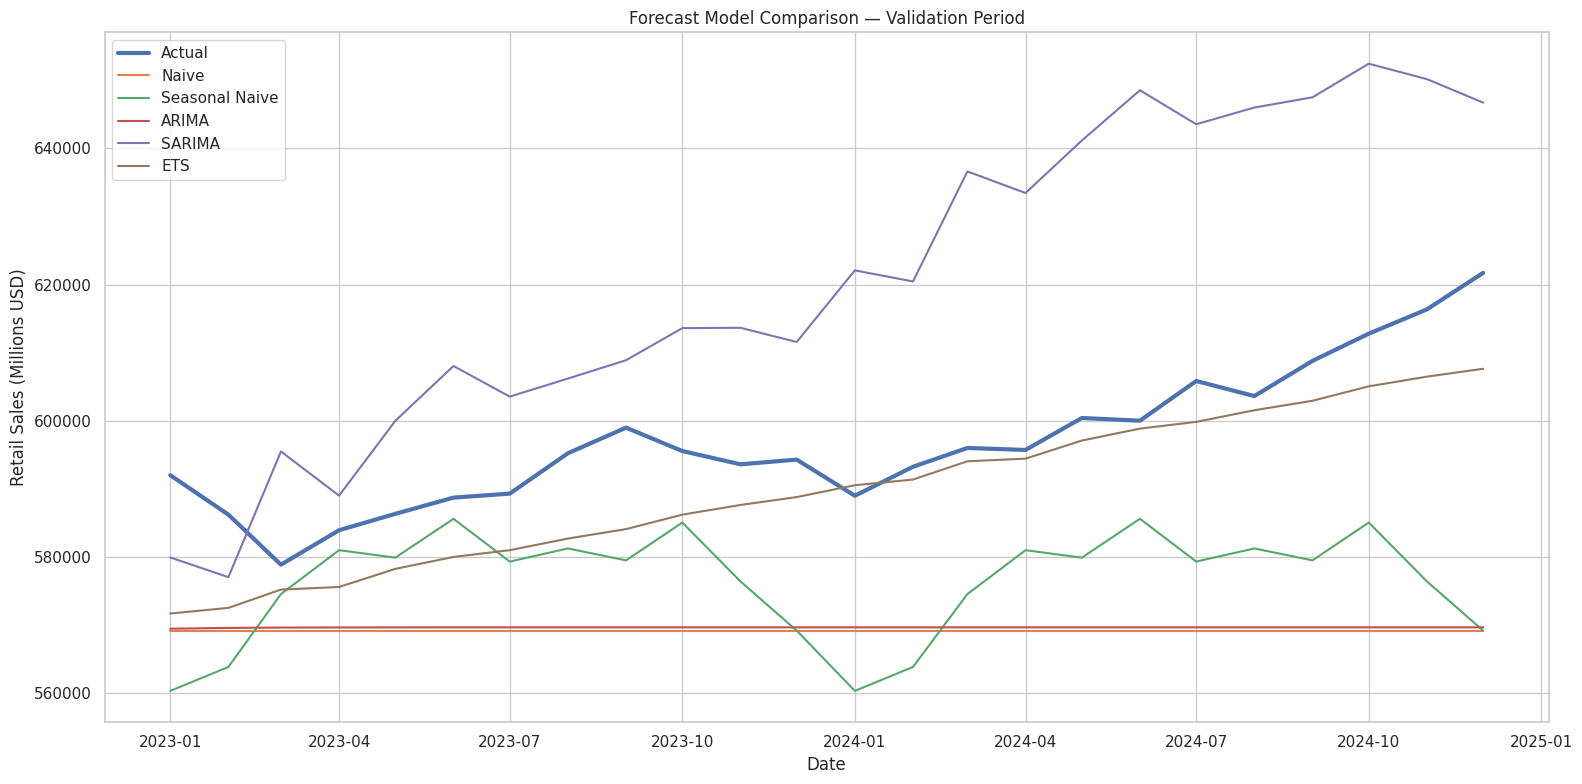

In [81]:
plt.figure(figsize=(16, 8))

plt.plot(
    validation.index,
    validation,
    label="Actual",
    linewidth=3
)

plt.plot(
    validation.index,
    naive_forecast,
    label="Naive"
)

plt.plot(
    validation.index,
    seasonal_naive_forecast,
    label="Seasonal Naive"
)

plt.plot(
    validation.index,
    arima_forecast,
    label="ARIMA"
)

plt.plot(
    validation.index,
    sarima_forecast,
    label="SARIMA"
)

plt.plot(
    validation.index,
    ets_forecast,
    label="ETS"
)

plt.title(
    "Forecast Model Comparison — Validation Period"
)

plt.xlabel("Date")
plt.ylabel("Retail Sales (Millions USD)")

plt.legend()

plt.tight_layout()

plt.show()

In [82]:
development_data = pd.concat([
    train,
    validation
])

In [83]:
seasonal_naive_test_forecast = pd.Series(
    [
        development_data.iloc[-12 + (i % 12)]
        for i in range(len(test))
    ],
    index=test.index
)

seasonal_naive_test_mae = mean_absolute_error(
    test,
    seasonal_naive_test_forecast
)

seasonal_naive_test_rmse = np.sqrt(
    mean_squared_error(
        test,
        seasonal_naive_test_forecast
    )
)

seasonal_naive_test_mape = (
    np.mean(
        np.abs(
            (
                test
                - seasonal_naive_test_forecast
            )
            / test
        )
    ) * 100
)

print("FINAL SEASONAL NAIVE TEST PERFORMANCE")
print("--------------------------------------")
print("MAE :", round(seasonal_naive_test_mae, 2))
print("RMSE:", round(seasonal_naive_test_rmse, 2))
print("MAPE:", round(seasonal_naive_test_mape, 2), "%")

FINAL SEASONAL NAIVE TEST PERFORMANCE
--------------------------------------
MAE : 35038.0
RMSE: 39185.1
MAPE: 5.45 %


In [84]:
final_arima = ARIMA(
    development_data,
    order=(1, 1, 1)
)

final_arima_fit = final_arima.fit()

arima_test_forecast = final_arima_fit.forecast(
    steps=len(test)
)

arima_test_mae = mean_absolute_error(
    test,
    arima_test_forecast
)

arima_test_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_test_forecast
    )
)

arima_test_mape = (
    np.mean(
        np.abs(
            (
                test
                - arima_test_forecast
            )
            / test
        )
    ) * 100
)

print("FINAL ARIMA TEST PERFORMANCE")
print("----------------------------")
print("MAE :", round(arima_test_mae, 2))
print("RMSE:", round(arima_test_rmse, 2))
print("MAPE:", round(arima_test_mape, 2), "%")

FINAL ARIMA TEST PERFORMANCE
----------------------------
MAE : 16685.87
RMSE: 21886.74
MAPE: 2.57 %


In [85]:
final_sarima = SARIMAX(
    development_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(
    disp=False
)

sarima_test_forecast = final_sarima_fit.forecast(
    steps=len(test)
)

sarima_test_mae = mean_absolute_error(
    test,
    sarima_test_forecast
)

sarima_test_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_test_forecast
    )
)

sarima_test_mape = (
    np.mean(
        np.abs(
            (
                test
                - sarima_test_forecast
            )
            / test
        )
    ) * 100
)

print("FINAL SARIMA TEST PERFORMANCE")
print("-----------------------------")
print("MAE :", round(sarima_test_mae, 2))
print("RMSE:", round(sarima_test_rmse, 2))
print("MAPE:", round(sarima_test_mape, 2), "%")

FINAL SARIMA TEST PERFORMANCE
-----------------------------
MAE : 10692.59
RMSE: 12394.06
MAPE: 1.7 %


In [86]:
final_ets = ExponentialSmoothing(
    development_data,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_ets_fit = final_ets.fit(
    optimized=True
)

ets_test_forecast = final_ets_fit.forecast(
    steps=len(test)
)

ets_test_mae = mean_absolute_error(
    test,
    ets_test_forecast
)

ets_test_rmse = np.sqrt(
    mean_squared_error(
        test,
        ets_test_forecast
    )
)

ets_test_mape = (
    np.mean(
        np.abs(
            (
                test
                - ets_test_forecast
            )
            / test
        )
    ) * 100
)

print("FINAL ETS TEST PERFORMANCE")
print("--------------------------")
print("MAE :", round(ets_test_mae, 2))
print("RMSE:", round(ets_test_rmse, 2))
print("MAPE:", round(ets_test_mape, 2), "%")

FINAL ETS TEST PERFORMANCE
--------------------------
MAE : 7484.08
RMSE: 8101.02
MAPE: 1.18 %


In [87]:
final_test_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "ARIMA(1,1,1)",
        "SARIMA(1,1,1)(1,1,1,12)",
        "ETS"
    ],
    "MAE": [
        seasonal_naive_test_mae,
        arima_test_mae,
        sarima_test_mae,
        ets_test_mae
    ],
    "RMSE": [
        seasonal_naive_test_rmse,
        arima_test_rmse,
        sarima_test_rmse,
        ets_test_rmse
    ],
    "MAPE": [
        seasonal_naive_test_mape,
        arima_test_mape,
        sarima_test_mape,
        ets_test_mape
    ]
})

final_test_comparison = final_test_comparison.round(2)

final_test_comparison.sort_values("RMSE")

,Model,MAE,RMSE,MAPE
3,ETS,7484.08,8101.02,1.18
2,"SARIMA(1,1,1)(1,1,1,12)",10692.59,12394.06,1.70
1,"ARIMA(1,1,1)",16685.87,21886.74,2.57
0,Seasonal Naive,35038.00,39185.10,5.45


## Final Model Selection

The final model was selected based on out-of-sample performance on the previously unseen test period.

Although the Seasonal Naive model performed best during the initial validation stage, its performance deteriorated substantially on the final test period.

The Exponential Smoothing (ETS) model achieved the lowest MAE, RMSE, and MAPE among the evaluated models.

Therefore, ETS was selected as the final forecasting model.

In [88]:
final_winner = final_test_comparison.loc[
    final_test_comparison["RMSE"].idxmin()
]

final_winner

,3
Model,ETS
MAE,7484.08
RMSE,8101.02
MAPE,1.18


In [89]:
ets_rmse = final_test_comparison.loc[
    final_test_comparison["Model"] == "ETS",
    "RMSE"
].iloc[0]

comparison = final_test_comparison.copy()

comparison["RMSE_improvement_vs_ETS_%"] = (
    (comparison["RMSE"] - ets_rmse)
    / comparison["RMSE"]
) * 100

comparison.round(2)

,Model,MAE,RMSE,MAPE,RMSE_improvement_vs_ETS_%
0,Seasonal Naive,35038.00,39185.10,5.45,79.33
1,"ARIMA(1,1,1)",16685.87,21886.74,2.57,62.99
2,"SARIMA(1,1,1)(1,1,1,12)",10692.59,12394.06,1.70,34.64
3,ETS,7484.08,8101.02,1.18,0.00


## Final Model Performance on the Test Period

The following visualization compares the actual retail sales values with the forecasts produced by the evaluated models during the unseen test period.

The test period was not used during model development or model selection.

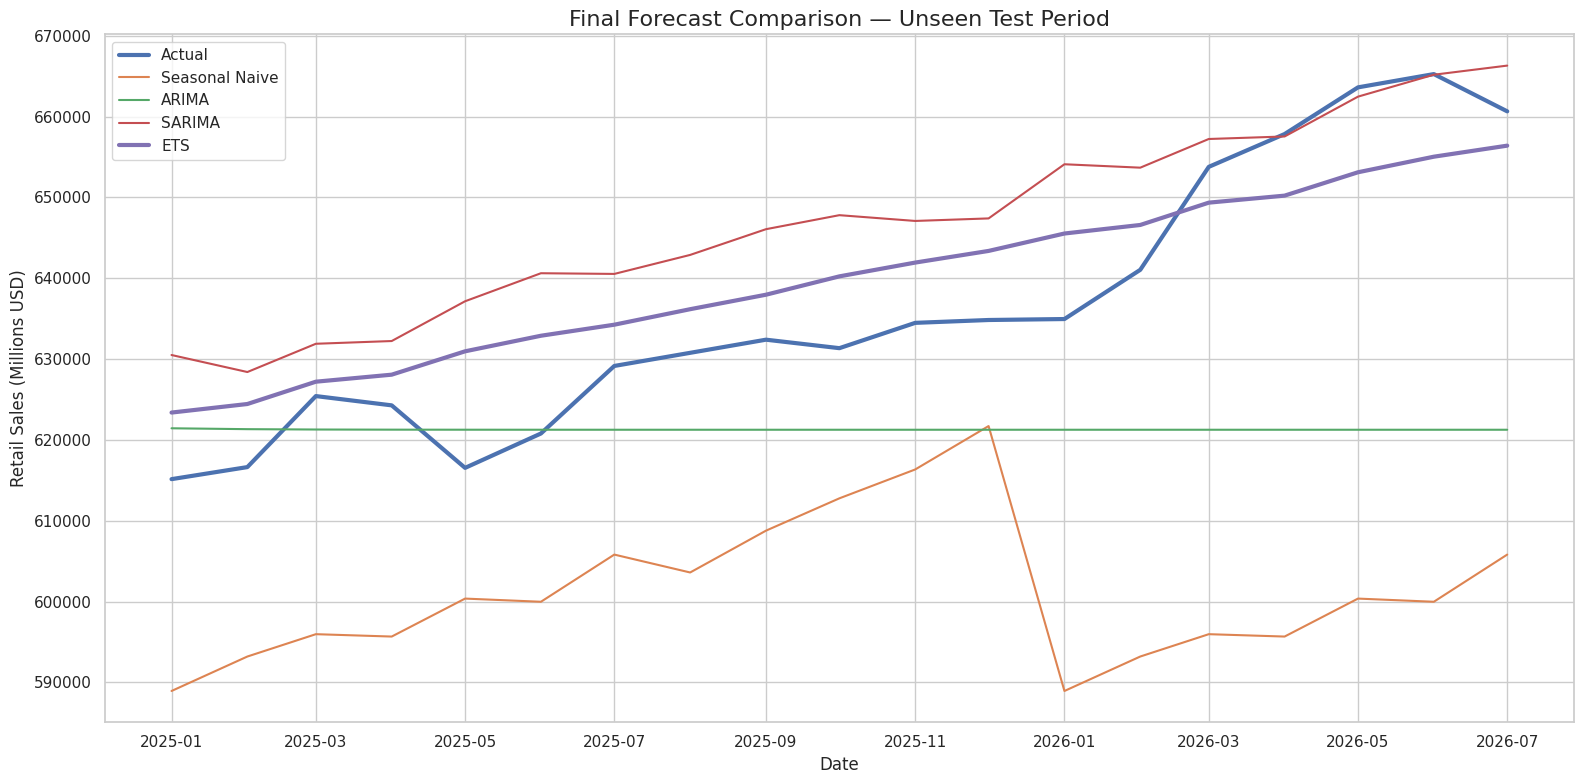

In [90]:
plt.figure(figsize=(16, 8))

plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=3
)

plt.plot(
    test.index,
    seasonal_naive_test_forecast,
    label="Seasonal Naive"
)

plt.plot(
    test.index,
    arima_test_forecast,
    label="ARIMA"
)

plt.plot(
    test.index,
    sarima_test_forecast,
    label="SARIMA"
)

plt.plot(
    test.index,
    ets_test_forecast,
    label="ETS",
    linewidth=3
)

plt.title(
    "Final Forecast Comparison — Unseen Test Period",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Retail Sales (Millions USD)")

plt.legend()

plt.tight_layout()

plt.show()

## Final Forecast

After evaluating the candidate models on the unseen test period, ETS was selected as the final forecasting model.

The final ETS model is now retrained using all available historical observations before generating the future 12-month forecast.

This ensures that the final forecasting model makes use of the maximum amount of historical information available.

In [91]:
full_series = df["sales"].dropna()

final_ets_model = ExponentialSmoothing(
    full_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_ets_fit = final_ets_model.fit(
    optimized=True
)

In [92]:
future_ets = final_ets_fit.forecast(
    steps=12
)

future_ets

,0
2026-08-01,663268.262169
2026-09-01,665175.533516
2026-10-01,667380.924360
2026-11-01,669260.298404
2026-12-01,670828.869440
2027-01-01,672788.990293
2027-02-01,673988.367825
2027-03-01,676893.004462
2027-04-01,677956.221499
2027-05-01,680680.049351


In [93]:
forecast_table = pd.DataFrame({
    "forecast_sales_million_usd": future_ets
})

forecast_table.round(2)

,forecast_sales_million_usd
2026-08-01,663268.26
2026-09-01,665175.53
2026-10-01,667380.92
2026-11-01,669260.30
2026-12-01,670828.87
2027-01-01,672788.99
2027-02-01,673988.37
2027-03-01,676893.00
2027-04-01,677956.22
2027-05-01,680680.05


In [94]:
total_forecast = future_ets.sum()

print(
    "Forecasted sales for next 12 months:",
    round(total_forecast, 2),
    "million USD"
)

Forecasted sales for next 12 months: 8085050.83 million USD


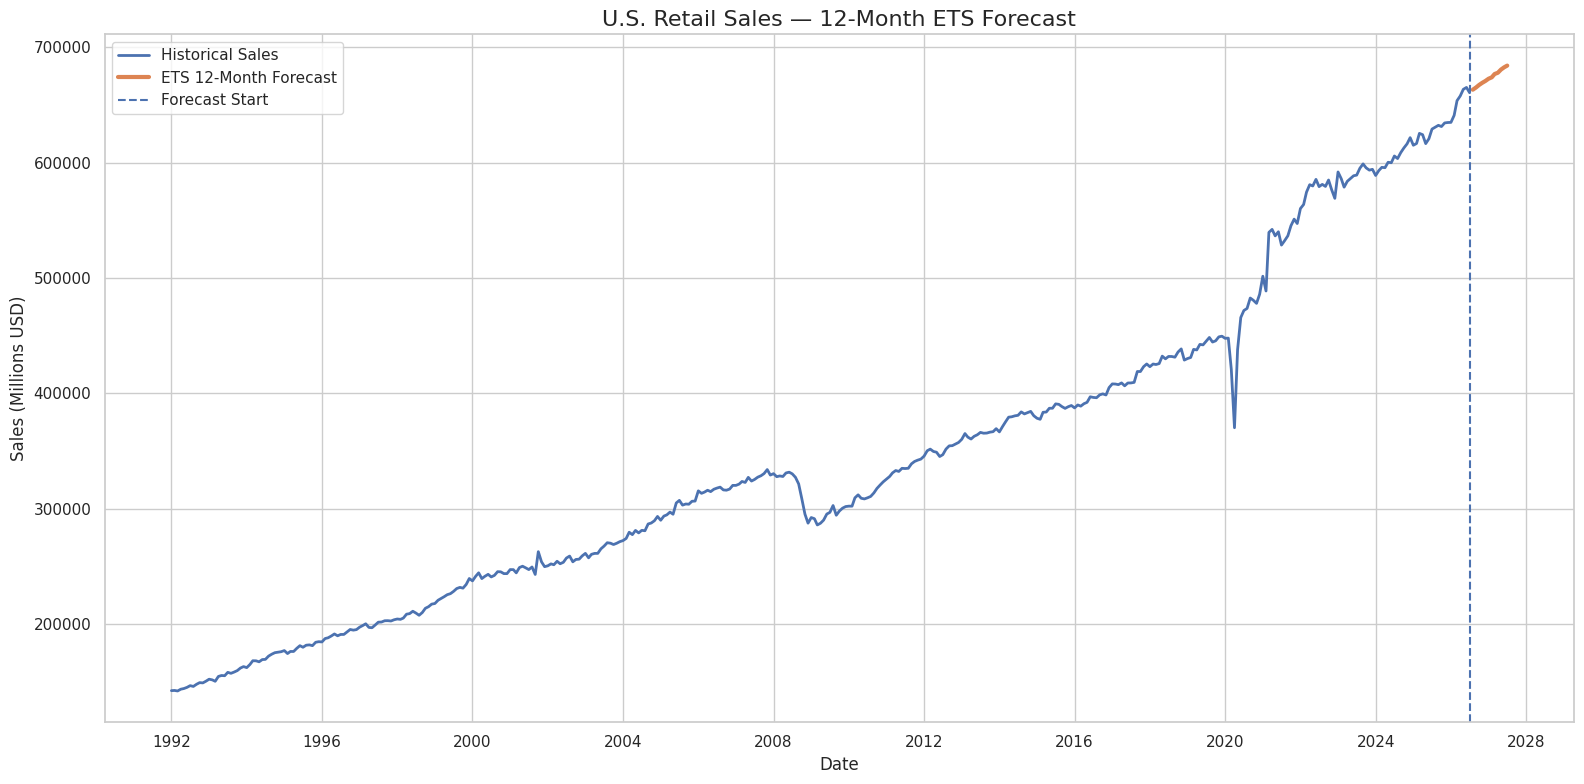

In [95]:
plt.figure(figsize=(16, 8))

plt.plot(
    full_series.index,
    full_series,
    label="Historical Sales",
    linewidth=2
)

plt.plot(
    future_ets.index,
    future_ets,
    label="ETS 12-Month Forecast",
    linewidth=3
)

plt.axvline(
    full_series.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title(
    "U.S. Retail Sales — 12-Month ETS Forecast",
    fontsize=16
)

plt.xlabel("Date")

plt.ylabel(
    "Sales (Millions USD)"
)

plt.legend()

plt.tight_layout()

plt.show()

In [96]:
plt.savefig(
    "revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

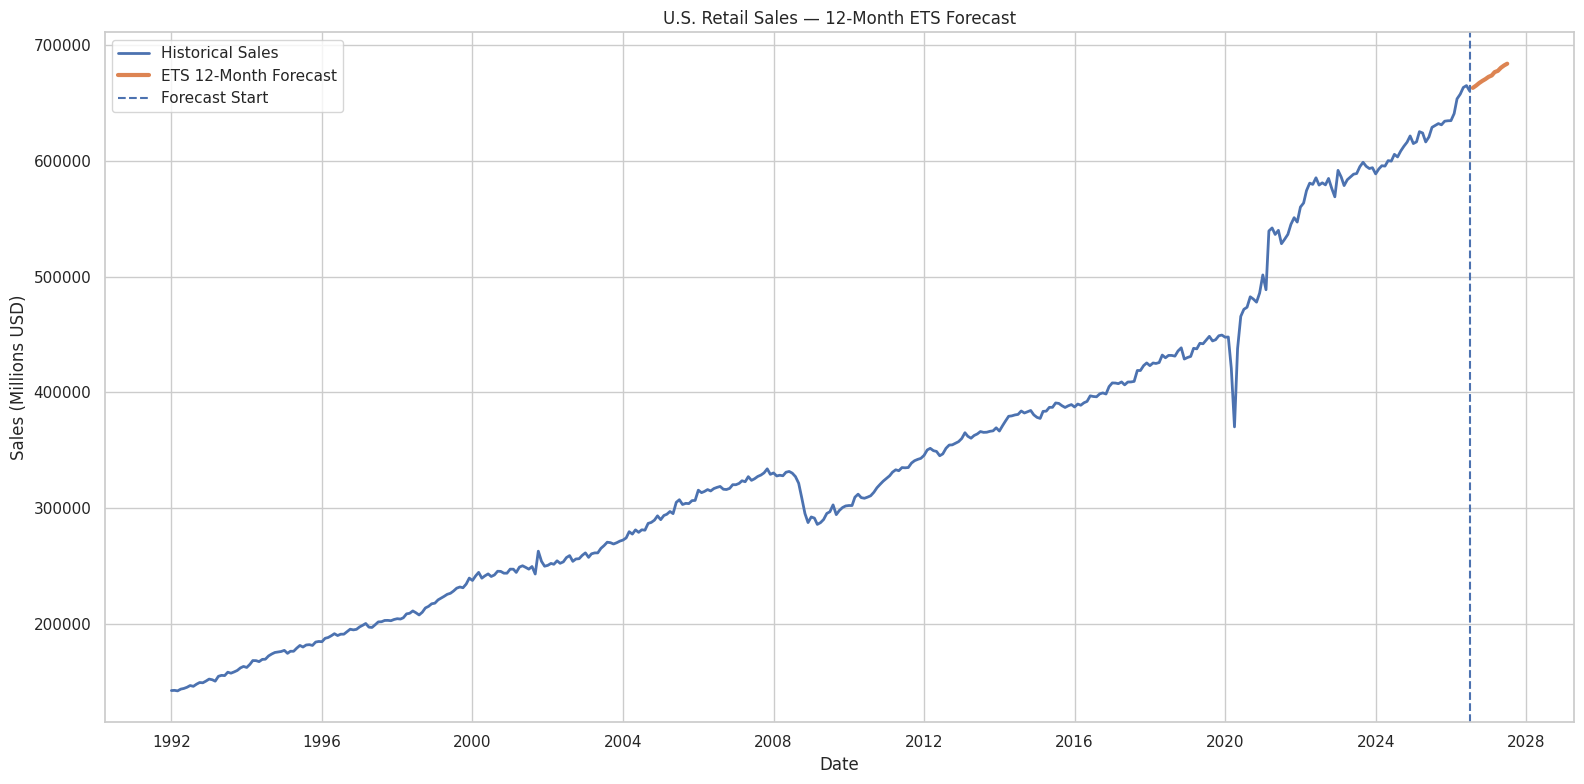

In [97]:
plt.figure(figsize=(16, 8))

plt.plot(
    full_series.index,
    full_series,
    label="Historical Sales",
    linewidth=2
)

plt.plot(
    future_ets.index,
    future_ets,
    label="ETS 12-Month Forecast",
    linewidth=3
)

plt.axvline(
    full_series.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title(
    "U.S. Retail Sales — 12-Month ETS Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales (Millions USD)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
final_test_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

forecast_table.to_csv(
    "future_revenue_forecast.csv"
)

In [99]:
last_actual = full_series.iloc[-1]

first_forecast = future_ets.iloc[0]

next_month_growth = (
    (first_forecast - last_actual)
    / last_actual
) * 100

print(
    "Forecast growth for first month:",
    round(next_month_growth, 2),
    "%"
)

Forecast growth for first month: 0.4 %


In [100]:
last_12_months = full_series.iloc[-12:].sum()

next_12_months = future_ets.sum()

annual_growth = (
    (next_12_months - last_12_months)
    / last_12_months
) * 100

print(
    "Forecasted 12-month growth:",
    round(annual_growth, 2),
    "%"
)

Forecasted 12-month growth: 4.45 %


## 3. Forecast Results

After selecting ETS as the final forecasting model, the model was retrained using the complete historical dataset and used to generate a 12-month forecast.

### Forecasted Sales

The model forecasts total retail sales of approximately:

**$8.085 trillion**

over the next 12 months.

The forecast indicates:

- **First-month expected growth:** 0.40%
- **Expected 12-month growth:** 4.45%

The 12-month growth estimate compares the forecasted next twelve months with the previous twelve months of observed sales.

### Business Interpretation

The forecast suggests continued growth in retail sales over the next year, with the model estimating approximately **4.45% year-over-year growth**.

The relatively small first-month expected increase of **0.40%** suggests that the model does not anticipate an immediate sharp change in sales levels.

However, the forecast should be interpreted as a statistical estimate rather than a guaranteed outcome because future sales may be affected by economic conditions, consumer behavior, inflation, interest rates, policy changes, and other external factors.

In [101]:
final_test_comparison.round(2)

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,35038.00,39185.10,5.45
1,"ARIMA(1,1,1)",16685.87,21886.74,2.57
2,"SARIMA(1,1,1)(1,1,1,12)",10692.59,12394.06,1.70
3,ETS,7484.08,8101.02,1.18


## Final Model Performance Comparison

The final test results demonstrate a clear difference in forecasting performance between the evaluated models.

ETS achieved the lowest error across all three evaluation metrics.

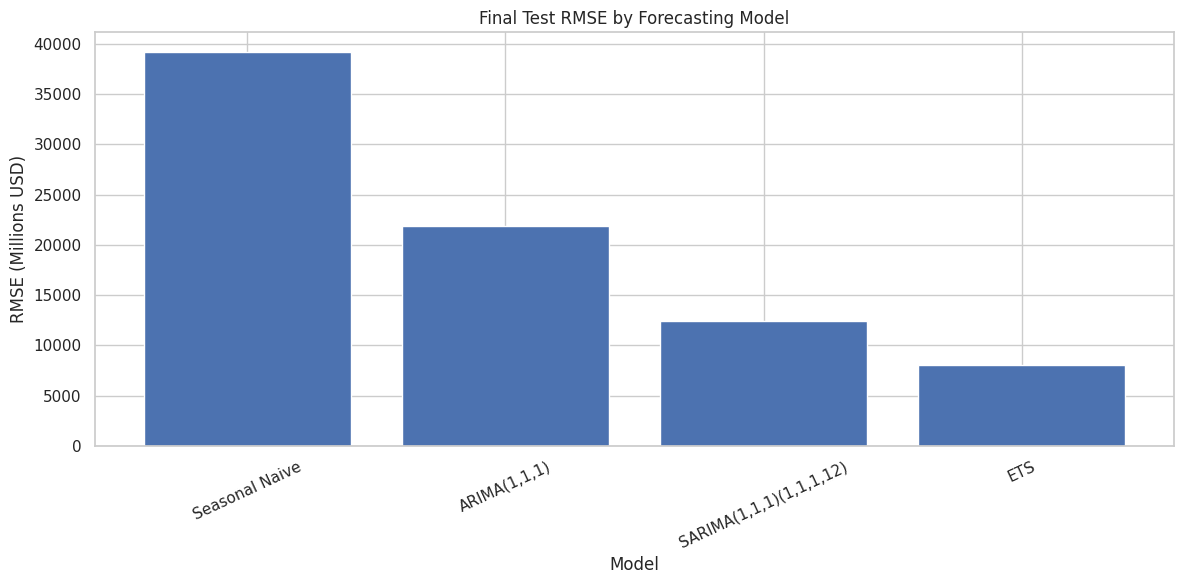

In [102]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_test_comparison["Model"],
    final_test_comparison["RMSE"]
)

plt.title("Final Test RMSE by Forecasting Model")
plt.xlabel("Model")
plt.ylabel("RMSE (Millions USD)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# Executive Summary

This project developed a financial time-series forecasting model using real monthly U.S. retail sales data from the U.S. Census Bureau, accessed through the Federal Reserve Economic Data (FRED) platform.

Five forecasting approaches were evaluated:

1. Naive
2. Seasonal Naive
3. ARIMA
4. SARIMA
5. Exponential Smoothing (ETS)

The models were evaluated using MAE, RMSE, and MAPE with a chronological train-validation-test methodology.

The initial validation stage identified Seasonal Naive as the strongest model. However, evaluation on the previously unseen test period showed that ETS generalized substantially better.

ETS achieved:

- **MAE:** 7,484.08 million USD
- **RMSE:** 8,101.02 million USD
- **MAPE:** 1.18%

The final ETS model was retrained using the complete historical dataset and forecast the following 12 months.

The forecast estimates approximately **$8.085 trillion** in total retail sales over the next 12 months, representing approximately **4.45% growth** compared with the previous twelve-month period.

### Key Insight

The project demonstrates that greater model complexity does not automatically result in better forecasting performance. Model selection should be based on out-of-sample performance and the ability of a model to generalize to unseen observations.

### Business Value

The resulting forecast can support:

- Revenue planning
- Budget preparation
- Inventory planning
- Workforce planning
- Capacity planning
- Strategic decision-making

The forecast should nevertheless be interpreted alongside external economic indicators because historical time-series patterns alone cannot fully capture unexpected changes in the economic environment.

In [103]:
# Save model comparison
final_test_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

# Save future forecast
forecast_table.to_csv(
    "future_revenue_forecast.csv"
)

print("Files saved successfully.")

Files saved successfully.
